# E0 — Can the proposed safety-defect measurements pass controlled tests?

**TL;DR.** On enumerated controls, the exact audit should report zero for an injective code and
recover the full planted defect for an explicit fold. A near-collision should switch only when its
pre-registered radius reaches the planted separation. Jointly scaling codes and radii should leave
the result unchanged. In contrast, the unthresholded nearest-unsafe-neighbor fraction should vary
with sample density and class balance even for an injective encoder. These are measurement gates,
not empirical evidence about trained neural networks.

This notebook is a deterministic, CPU-sized experiment log for Gate G1. It is generated by
`scripts/build_notebooks.py`; edit the generator rather than hand-editing notebook JSON.

## Context, assumptions, and pass criteria

- Safety is `h(x) >= 0`; unsafe means the strict condition `h(x) < 0`.
- Every synthetic state is enumerated, so exact-code results are finite ground truth, not a
  population estimate.
- A radius is fixed before inspecting an outcome. Raw latent radii have no invariant meaning under
  rescaling, so the rescaling control transforms the radius with the code.
- The nearest-neighbor statistic is retained only to demonstrate why it cannot certify an exact
  collision.

The notebook fails loudly unless: identity defect = 0; folded defect = planted maximum; the
near-collision transition is recovered; the rescaling equality holds; and the action-conflict
fixture is detected.

In [1]:
from pathlib import Path
import json
import random
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif (ROOT / "LatentSafety" / "src").exists():
    ROOT = ROOT / "LatentSafety"
if not (ROOT / "src" / "latent_safety").exists():
    raise RuntimeError(f"Could not locate repository root from {Path.cwd()}")
sys.path.insert(0, str(ROOT / "src"))

from latent_safety.metrics.action import audit_exact_action_fibers
from latent_safety.metrics.defect import empirical_defect_curve, nearest_unsafe_diagnostic
from latent_safety.metrics.finite import audit_finite_static_fibers
from latent_safety.synthetic import make_aliasing_fixture
from latent_safety.benchmarks import (
    ObservationSpec,
    make_action_conflict_pair,
    make_static_aliasing_pair,
    reconstruct_current_velocity,
)

SEED = 20260821
random.seed(SEED)
np.random.seed(SEED)
print({
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "seed": SEED,
    "working_directory": "notebooks",
})

{'python': '3.13.5', 'numpy': '2.4.2', 'matplotlib': '3.10.6', 'seed': 20260821, 'working_directory': 'notebooks'}


## 1. Exact identity and planted-collision controls

In [2]:
fixture = make_aliasing_fixture(n_pairs=40, max_margin=1.0, seed=SEED)
identity_audit = audit_finite_static_fibers(fixture.faithful_latents, fixture.margins)
folded_audit = audit_finite_static_fibers(fixture.collapsed_latents, fixture.margins)

exact_rows = [
    {
        "representation": "injective control",
        "mixed_fibers": identity_audit.mixed_fiber_count,
        "collided_safe_states": identity_audit.collided_safe_count,
        "exact_defect": identity_audit.exact_defect,
    },
    {
        "representation": "explicit fold",
        "mixed_fibers": folded_audit.mixed_fiber_count,
        "collided_safe_states": folded_audit.collided_safe_count,
        "exact_defect": folded_audit.exact_defect,
    },
]
display(exact_rows)

assert identity_audit.exact_defect == 0.0
assert folded_audit.exact_defect == 1.0
assert folded_audit.mixed_fiber_count == 40

[{'representation': 'injective control',
  'mixed_fibers': 0,
  'collided_safe_states': 0,
  'exact_defect': 0.0},
 {'representation': 'explicit fold',
  'mixed_fibers': 40,
  'collided_safe_states': 40,
  'exact_defect': 1.0}]

## 2. A known near-collision and a scale-equivariance check

Each safe state and its unsafe partner are separated by exactly `eta` in code space; different
pairs are placed far apart. Therefore the robust witness is zero for radii below `eta` and recovers
the largest safe margin at and above `eta`. This checks the operational-radius implementation.

In [3]:
eta = 0.08
pair_margins = np.linspace(0.05, 1.0, 30)
near_codes = []
near_margins = []
for index, margin in enumerate(pair_margins):
    anchor = 4.0 * index
    near_codes.extend(((anchor, 0.0), (anchor, eta)))
    near_margins.extend((float(margin), -float(margin)))

deltas = (0.0, 0.02, 0.04, 0.079, 0.08, 0.10, 0.16)
near_curve = empirical_defect_curve(near_codes, near_margins, deltas=deltas)
near_values = [point.witness_margin for point in near_curve]

scale = 7.5
scaled_codes = [tuple(scale * value for value in code) for code in near_codes]
scaled_curve = empirical_defect_curve(
    scaled_codes,
    near_margins,
    deltas=tuple(scale * delta for delta in deltas),
)
scaled_values = [point.witness_margin for point in scaled_curve]

display([
    {"delta": delta, "witness_margin": value}
    for delta, value in zip(deltas, near_values, strict=True)
])
assert all(value == 0.0 for delta, value in zip(deltas, near_values, strict=True) if delta < eta)
assert near_values[deltas.index(eta)] == 1.0
assert np.allclose(near_values, scaled_values, atol=1e-12, rtol=0.0)

[{'delta': 0.0, 'witness_margin': 0.0},
 {'delta': 0.02, 'witness_margin': 0.0},
 {'delta': 0.04, 'witness_margin': 0.0},
 {'delta': 0.079, 'witness_margin': 0.0},
 {'delta': 0.08, 'witness_margin': 1.0},
 {'delta': 0.1, 'witness_margin': 1.0},
 {'delta': 0.16, 'witness_margin': 1.0}]

## 3. Why unthresholded 1-NN is only a diagnostic

All codes below are the physical scalar state itself, so the representation is injective and its
exact defect is zero. We alter only which finite samples happen to occur near the boundary. The
cross-boundary nearest-neighbor fraction moves anyway.

In [4]:
def density_case(n_safe: int) -> dict[str, float | int]:
    safe = [0.001] + list(np.linspace(0.10, 1.0, n_safe - 1))
    unsafe = [-0.001] + list(-np.linspace(0.10, 1.0, n_safe - 1))
    states = safe + unsafe
    result = nearest_unsafe_diagnostic([(value,) for value in states], states)
    exact = audit_finite_static_fibers([(value,) for value in states], states)
    return {
        "safe_samples": n_safe,
        "unsafe_samples": n_safe,
        "1nn_cross_fraction": result.cross_boundary_fraction,
        "exact_defect": exact.exact_defect,
    }


def balance_case(n_unsafe: int) -> dict[str, float | int]:
    safe = [0.01] + list(np.linspace(0.05, 1.0, 49))
    unsafe = list(-np.arange(1, n_unsafe + 1) / (n_unsafe + 1))
    states = safe + unsafe
    result = nearest_unsafe_diagnostic([(value,) for value in states], states)
    exact = audit_finite_static_fibers([(value,) for value in states], states)
    return {
        "safe_samples": len(safe),
        "unsafe_samples": n_unsafe,
        "1nn_cross_fraction": result.cross_boundary_fraction,
        "exact_defect": exact.exact_defect,
    }


density_rows = [density_case(size) for size in (10, 25, 50, 100, 250)]
balance_rows = [balance_case(size) for size in (5, 10, 25, 50, 100, 250)]
display(Markdown("**Sample-density sweep**"))
display(density_rows)
display(Markdown("**Class-balance sweep**"))
display(balance_rows)

assert all(row["exact_defect"] == 0.0 for row in density_rows + balance_rows)
assert len({row["1nn_cross_fraction"] for row in density_rows}) > 1
assert len({row["1nn_cross_fraction"] for row in balance_rows}) > 1

**Sample-density sweep**

[{'safe_samples': 10,
  'unsafe_samples': 10,
  '1nn_cross_fraction': 0.1,
  'exact_defect': 0.0},
 {'safe_samples': 25,
  'unsafe_samples': 25,
  '1nn_cross_fraction': 0.04,
  'exact_defect': 0.0},
 {'safe_samples': 50,
  'unsafe_samples': 50,
  '1nn_cross_fraction': 0.02,
  'exact_defect': 0.0},
 {'safe_samples': 100,
  'unsafe_samples': 100,
  '1nn_cross_fraction': 0.01,
  'exact_defect': 0.0},
 {'safe_samples': 250,
  'unsafe_samples': 250,
  '1nn_cross_fraction': 0.004,
  'exact_defect': 0.0}]

**Class-balance sweep**

[{'safe_samples': 50,
  'unsafe_samples': 5,
  '1nn_cross_fraction': 0.0,
  'exact_defect': 0.0},
 {'safe_samples': 50,
  'unsafe_samples': 10,
  '1nn_cross_fraction': 0.0,
  'exact_defect': 0.0},
 {'safe_samples': 50,
  'unsafe_samples': 25,
  '1nn_cross_fraction': 0.0,
  'exact_defect': 0.0},
 {'safe_samples': 50,
  'unsafe_samples': 50,
  '1nn_cross_fraction': 0.02,
  'exact_defect': 0.0},
 {'safe_samples': 50,
  'unsafe_samples': 100,
  '1nn_cross_fraction': 0.02,
  'exact_defect': 0.0},
 {'safe_samples': 50,
  'unsafe_samples': 250,
  '1nn_cross_fraction': 0.02,
  'exact_defect': 0.0}]

## 4. Dynamic/action-information control

In [5]:
# At their shared code, state 0 permits only action 0 and state 1 permits only action 1.
action_audit = audit_exact_action_fibers(
    latents=[(0.0,), (0.0,), (1.0,)],
    action_safety_margins=[(1.0, -1.0), (-1.0, 1.0), (0.5, 0.2)],
)
display(action_audit)

assert action_audit.individually_viable_fiber_count == 1
assert action_audit.conflicting_fiber_count == 1
assert action_audit.worst_required_violation == 1.0

ActionFiberAudit(fiber_count=2, nontrivial_fiber_count=1, individually_viable_fiber_count=1, conflicting_fiber_count=1, conflict_fraction=1.0, worst_required_violation=1.0)

## 5. Partial-observability floor and history recovery

The controlled double integrator separates two failure modes analytically. A saturated position
sensor aliases a safe and unsafe state with known static witness `0.5`. Position-only observation
aliases two currently safe states with opposite hidden velocities: static labels agree, but their
one-step safe-action sets are disjoint and force violation `0.25` on the finite grid. A causal
two-position/action history reconstructs velocity exactly in the noise-free benchmark and separates
that action-conflicted pair.

In [6]:
static_pair = make_static_aliasing_pair()
dynamic_pair = make_action_conflict_pair()

static_sensor_audit = audit_finite_static_fibers(
    [static_pair.left_observation, static_pair.right_observation],
    static_pair.safety_margins,
)
dynamic_static_audit = audit_finite_static_fibers(
    [dynamic_pair.left_observation, dynamic_pair.right_observation],
    dynamic_pair.safety_margins,
)
dynamic_action_audit = audit_exact_action_fibers(
    [dynamic_pair.left_observation, dynamic_pair.right_observation],
    dynamic_pair.action_safety_margins,
)

history_observer = ObservationSpec.position_action_history(history_length=2)
previous_action = 0.0
left_predecessor = dynamic_pair.system.predecessor(
    dynamic_pair.left_state, previous_action
)
right_predecessor = dynamic_pair.system.predecessor(
    dynamic_pair.right_state, previous_action
)
left_history = history_observer.observe(
    (left_predecessor, dynamic_pair.left_state), (previous_action,)
)
right_history = history_observer.observe(
    (right_predecessor, dynamic_pair.right_state), (previous_action,)
)
recovered_velocities = (
    reconstruct_current_velocity(
        previous_position=left_predecessor.position,
        current_position=dynamic_pair.left_state.position,
        previous_action=previous_action,
        time_step=dynamic_pair.system.time_step,
    ),
    reconstruct_current_velocity(
        previous_position=right_predecessor.position,
        current_position=dynamic_pair.right_state.position,
        previous_action=previous_action,
        time_step=dynamic_pair.system.time_step,
    ),
)
history_action_audit = audit_exact_action_fibers(
    [left_history, right_history], dynamic_pair.action_safety_margins
)

partial_observability_summary = {
    "saturated_sensor_static_defect": static_sensor_audit.exact_defect,
    "position_only_static_defect_for_dynamic_pair": dynamic_static_audit.exact_defect,
    "position_only_forced_action_violation": dynamic_action_audit.worst_required_violation,
    "history_observations_separate_pair": left_history != right_history,
    "history_recovered_velocities": recovered_velocities,
    "history_action_conflicts": history_action_audit.conflicting_fiber_count,
}
display(partial_observability_summary)

assert static_sensor_audit.exact_defect == 0.5
assert dynamic_static_audit.exact_defect == 0.0
assert dynamic_action_audit.worst_required_violation == 0.25
assert recovered_velocities == (
    dynamic_pair.left_state.velocity,
    dynamic_pair.right_state.velocity,
)
assert history_action_audit.conflicting_fiber_count == 0

{'saturated_sensor_static_defect': 0.5,
 'position_only_static_defect_for_dynamic_pair': 0.0,
 'position_only_forced_action_violation': 0.25,
 'history_observations_separate_pair': True,
 'history_recovered_velocities': (1.25, -1.25),
 'history_action_conflicts': 0}

## 6. Visual audit and machine-checked gate summary

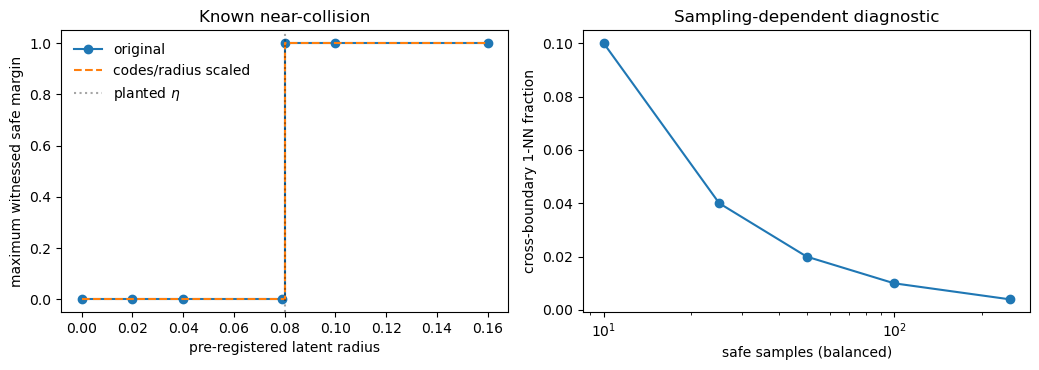

{
  "action_conflict_detected": true,
  "fold_recovers_planted_defect": true,
  "history_separates_hidden_velocity": true,
  "injective_exact_zero": true,
  "joint_rescaling_invariant": true,
  "near_collision_transition": true,
  "nearest_neighbor_is_sampling_sensitive": true,
  "observation_floor_recovered": true
}


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
axes[0].step(deltas, near_values, where="post", marker="o", label="original")
axes[0].step(deltas, scaled_values, where="post", linestyle="--", label="codes/radius scaled")
axes[0].axvline(eta, color="black", alpha=0.35, linestyle=":", label=r"planted $\eta$")
axes[0].set(xlabel="pre-registered latent radius", ylabel="maximum witnessed safe margin")
axes[0].set_title("Known near-collision")
axes[0].legend(frameon=False)

axes[1].plot(
    [row["safe_samples"] for row in density_rows],
    [row["1nn_cross_fraction"] for row in density_rows],
    marker="o",
)
axes[1].set(xlabel="safe samples (balanced)", ylabel="cross-boundary 1-NN fraction")
axes[1].set_title("Sampling-dependent diagnostic")
axes[1].set_xscale("log")
fig.tight_layout()
plt.show()

gates = {
    "injective_exact_zero": identity_audit.exact_defect == 0.0,
    "fold_recovers_planted_defect": folded_audit.exact_defect == 1.0,
    "near_collision_transition": near_values[deltas.index(eta)] == 1.0,
    "joint_rescaling_invariant": bool(np.allclose(near_values, scaled_values)),
    "nearest_neighbor_is_sampling_sensitive": (
        len({row["1nn_cross_fraction"] for row in density_rows}) > 1
        and len({row["1nn_cross_fraction"] for row in balance_rows}) > 1
    ),
    "action_conflict_detected": action_audit.conflicting_fiber_count == 1,
    "observation_floor_recovered": (
        static_sensor_audit.exact_defect == 0.5
        and dynamic_action_audit.worst_required_violation == 0.25
    ),
    "history_separates_hidden_velocity": (
        left_history != right_history and history_action_audit.conflicting_fiber_count == 0
    ),
}
assert all(gates.values()), gates
print(json.dumps(gates, indent=2, sort_keys=True))

## Takeaways and next decision

The implemented measurements pass these deterministic controls. The main practical lesson is that
an exact-code audit and a fixed-radius robust audit answer different questions, while an
unthresholded nearest-neighbor mismatch answers neither one without calibration. The action-fiber
test also catches information loss that the static safe/unsafe label alone cannot see.

**Decision status:** E0 is only partially passed. These controls validate reference semantics, but
do not yet validate continuous collision search, uncertainty-set calibration, sampling coverage,
or confidence statements. No trained-model or ICML claim should cite this notebook as empirical
evidence. The next gate is the controlled dynamical benchmark plus boundary-stratified held-out
evaluation.